# Noise analysis in Le Prehaut pig farm

The maternity room is ventilated by a ventilation system whose motors are located outside the room.
The ventilation system generates a permanent noise that adds to the other noises in the barn.

In this Notebook we apply the traditional beamforming algorithm and visualize the result obtained.
A video is generated that associates the sound with the formed channels (see ./tmp).

## Getting started

Get the file `megamicros.sh` from the Megamicros repository at `https://gitlabsu.sorbonne-universite.fr/megamicros/Megamicros`.

Build your local Megamicros project directory:

```bash
    $ > mkdir /your_path/Megamicros && cd /your_path/Megamicros
```

Put the `megamicros.sh` script in your Megamicros project directory and make it executable

Clone the Megamicros project:

```bash
    $ > source megamicros.sh install -u user:password
```

Where `user:password` is your *gitlabsu* login and password separated by a colon (:).
Once the installation is completed, you should have your virtual environnement (venv) activated.

Install the python requirements:

```bash
    (venv) $ > pip install Megamicros/requirements.txt
```

Verify that your PYTHONPATH is set:

```bash
    (venv) $ > echo $PYTHONPATH
```

Go to the *Megamicros_ailab* notebooks directory:

```bash
    (venv) $ > cd Megamicros_ailab/src/megamicros_ailab/notebooks
```

Test the *diffuse_noise.ipynb* notebook

```bash
    (venv) $ > jupyter-lab
```

You may prefere using Visual Studio Code...

## Updating

If you have Megamicros already installed, please update it:

```bash
    $ > cd /your_path/Megamicros
    $ > source venv/bin/activate
    (venv) $ > source Megamicros/megamicros.sh pull
```

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
from IPython import display
from megamicros_ailab.antenna import Antenna, BmfAntenna, Mu32_Mems32_JetsonNano_0001
from megamicros_ailab.room import arrange_2D
from megamicros_aidb.query.db import AidbSession
from megamicros.data import MuAudio
from megamicros.log import log
from megamicros.audio import play, generate_moovie
from megamicros.core_base import MU_MEMS_SENSIBILITY

log.setLevel( "INFO" )

FRAME_LENGTH = 1024
SAMPLING_FREQUENCY = 10000
ROOM_SIZE = (8.40, 10.2, 2.05)          # 6 box + 1 couloir + 6 box + 6 box   
ANTENNA_POSITION = (2.95, 5.1, 2.03)    # au centre du couloir face aux cases 432, 433, 434, 435 et 422, 424, 426 et 428
SPACE_SAMPLING = (4, 4)                 # spatial sampling frequency (/meters)

LABEL_ID = 29                           # diffuse noise label                             
SOURCEFILE_ID = 7171                    # select noise sound from database
SAMPLE = 0                              # select the first signal

#a=6cm
#340/5000 = (lambda) = 7 cm / a (=6cm) = 1,13 rad = 60 degrés -> dans cette direction, effet spatial aliasing, repliement spectral/soatial, 
#2500 Hz -> *180/pi -> 129 degrés, 
#3500 Hz ->  

Get mesure signal from database

In [2]:
# Get signal mesure from database

with AidbSession(
    dbhost='http://dbwelfare.biimea.io/',
    login='ailab',
    email='bruno.gas@biimea.com',
    password='#T;uZnQ5UJ_JC~&' ) as session:
        label_id = LABEL_ID
        labelings_file = session.load_labelings( label_id=label_id )
        print( f"Etiquettages trouvés:" )
        for labeling_file in labelings_file:
            print( f" > [{labeling_file['sourcefile_id']}: {labeling_file['sourcefile_filename']}]")
        #sourcefile_id = int( input( 'Numéro identificateur du fichier à sélectionner:' ) )
        sourcefile_id = SOURCEFILE_ID
        limit = 100
        channels = list( np.arange( 32 ) + 1 )
        signals = session.load_labelized( sourcefile_id=sourcefile_id, label_id=label_id, limit=limit, channels=channels )
        
print( f"{len(signals)} section audio récupérées: " )
for idx, aud in enumerate( signals ):
    print( f"Audio[{idx}]: {aud} -> label={aud.label}, channels number: {aud.channels_number} ({aud.samples_number} samples)")

2023-08-23 00:05:14,103 [INFO]:  .Try connecting on endpoint database http://dbwelfare.biimea.io/...
2023-08-23 00:05:14,603 [INFO]:  .Got HTTP 200 status code from server
2023-08-23 00:05:14,604 [INFO]:  .Received CSRF token: 839LG2l9LrqvFdw3YdSNfpWHCxuNYE1x. Update session with
2023-08-23 00:05:14,605 [INFO]:  .Received session id: fu5pca8bkog8ixsd995haa76ao683c2m
2023-08-23 00:05:14,606 [INFO]:  .Successfully connected on http://dbwelfare.biimea.io/
2023-08-23 00:05:14,606 [INFO]:  .Downloading labelings from http://dbwelfare.biimea.io/...
2023-08-23 00:05:14,636 [INFO]:  .Received 1 labelings
2023-08-23 00:05:14,638 [INFO]:  .Downloading labelized audio files from http://dbwelfare.biimea.io/...
2023-08-23 00:05:14,672 [INFO]:  .Found 1 labelized audio files
2023-08-23 00:05:14,674 [INFO]:  .Limit is set to 100 audio files
2023-08-23 00:05:14,675 [INFO]:  .Downloading metadata for object 'sourcefile' [7171]...
2023-08-23 00:05:14,745 [INFO]:  Object sourcefile found with identifier 

Etiquettages trouvés:
 > [7171: mu5h-20220824-001853.h5]


2023-08-23 00:05:17,688 [INFO]:  .Trying to disconnect from database http://dbwelfare.biimea.io/...
2023-08-23 00:05:17,726 [INFO]:  .Logout successful.


I'm a NDarray signal with frame size = 53705 and frame number = 1
1 section audio récupérées: 
Audio[0]: 32 X 53705 audio signals (sf=10000.0 Hz) -> label=diffuse-noise, channels number: 32 (53705 samples)


In [3]:
# Build the antenna
antenna_square: Antenna = Mu32_Mems32_JetsonNano_0001

# Space quantization
sq_x = SPACE_SAMPLING[0]
sq_y = SPACE_SAMPLING[1]
nx: int = int( ROOM_SIZE[0] * sq_x )
ny: int = int( ROOM_SIZE[1] * sq_y )
ground_elevation = 0.20
space_q = arrange_2D( ROOM_SIZE, sq_x=sq_x, sq_y=sq_y, ground_elevation=ground_elevation )
space_q_2D = np.reshape( space_q, (nx, ny, 3) )

In [4]:
# Create antenna with beamformer
bmf_antenna: BmfAntenna = BmfAntenna( 
    mems = Mu32_Mems32_JetsonNano_0001.mems(),
    position = ANTENNA_POSITION,
    frame_length = FRAME_LENGTH,
    space_q = space_q,
    sampling_frequency = SAMPLING_FREQUENCY
)

2023-08-23 00:05:17,737 [INFO]:  .Build antenna with 32 MEMs at position [2.95 5.1  2.03]
2023-08-23 00:05:17,739 [INFO]:  .Buffered antenna set with frames of length 1024 samples
2023-08-23 00:05:17,740 [INFO]:  .Beamformer2D Initilization:
2023-08-23 00:05:17,741 [INFO]:   > Found antenna with 32 mems microphones at position [2.95 5.1  2.03]
2023-08-23 00:05:17,741 [INFO]:   > Frame length is 1024
2023-08-23 00:05:17,741 [INFO]:   > Time range: [0, 0.1023] s
2023-08-23 00:05:17,741 [INFO]:   > Frequency range: [0, 5000.0] Hz (513 beams)
2023-08-23 00:05:17,742 [INFO]:   > Space quantization: 1320 locations requested
2023-08-23 00:05:17,742 [INFO]:   > Build distances matrix D (1320 x 32)
2023-08-23 00:05:17,826 [INFO]:   > Build preformed channels matrix H (513 x 1320 x 32)


In [5]:
# Select a signal
#selected = int( input( f"Choisir un signal (0 à {len(signals)-1}): " ) )
selected = SAMPLE
antenna_output: MuAudio = signals[selected]

In [6]:
# Play original sound
left = np.array( antenna_output.channel(0) )
right = np.array( antenna_output.channel(1) )
sound = np.array( [left, right] )

In [7]:
display.display( display.Audio(sound, rate=SAMPLING_FREQUENCY ) )

In [8]:
bmf_antenna.set_data( antenna_output() )

In [9]:
# Comput BMF
BF: np.ndarray = np.zeros( (len(space_q),) )
E = []
imgs = []
for bf in bmf_antenna:
    E.append( np.sum( bf ) )
    BF += bf
    imgs.append( np.reshape( bf, (nx, ny) ).T )

2023-08-23 00:05:21,733 [INFO]:  .Create ./tmp directory...
2023-08-23 00:05:21,740 [INFO]:  .Generate images as png files without normalization...
2023-08-23 00:05:29,148 [INFO]:  .Generate video from png files...
2023-08-23 00:05:29,534 [INFO]:  .Generate sound wav file...
2023-08-23 00:05:29,535 [INFO]:  .Merge audio with video and make mp4 movie file...
2023-08-23 00:05:29,674 [INFO]:  .Movie saved
2023-08-23 00:05:29,674 [INFO]:  .Remove temporary png files...


audio saved


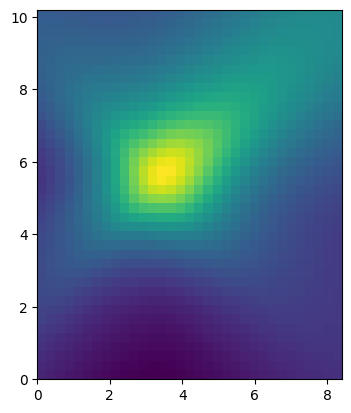

In [10]:
generate_moovie( 
    imgs, 
    rate=SAMPLING_FREQUENCY/FRAME_LENGTH, 
    sound=sound.astype( np.float32 ).T, 
    sampling_frequency=SAMPLING_FREQUENCY,
    norm=None,
    extent=( 0, ROOM_SIZE[0], 0, ROOM_SIZE[1] ),
)

In [11]:
display.Video('./tmp/movie.mp4', embed=True)

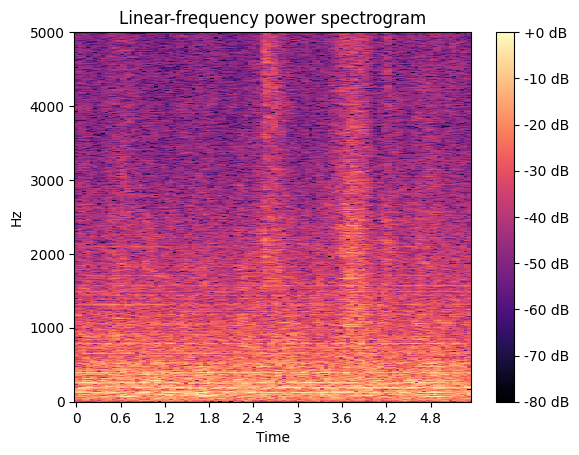

In [14]:
y = antenna_output.channel(0)/MU_MEMS_SENSIBILITY
sr = antenna_output.sampling_frequency
fig, ax = plt.subplots( nrows=1, ncols=1, sharex=True )
D = librosa.amplitude_to_db( np.abs( librosa.stft( y ) ), ref=np.max )
img = librosa.display.specshow(D, y_axis='linear', x_axis='time', sr=sr, ax=ax)
ax.set(title='Linear-frequency power spectrogram')
ax.label_outer()
fig.colorbar(img, ax=ax, format="%+2.f dB")